# 🌳 Day 4 — Tree-Based Models, SVM, and k-Nearest Neighbors

---

## 📖 Introduction

In the previous notebook, we built our first classification model using **Logistic Regression** and learned how to evaluate its performance using metrics such as the confusion matrix, precision, recall, F1-score, and ROC-AUC.

While Logistic Regression is simple, interpretable, and often serves as a strong baseline, it is not always the best model for every classification problem.

In this notebook, we will explore four widely used machine learning algorithms:

- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- k-Nearest Neighbors (k-NN)

Each algorithm approaches classification differently, making different assumptions about the data and offering unique strengths and weaknesses.

Rather than assuming one algorithm is universally superior, we will train all four models on the same dataset, evaluate them using identical metrics, and compare their performance objectively.

This notebook follows the same professional workflow used in previous days—from understanding the theory to applying it on a real-world dataset and interpreting the results.

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

- Explain how Decision Trees make predictions.
- Understand why Random Forests generally outperform a single decision tree.
- Describe how Support Vector Machines separate classes.
- Explain how k-Nearest Neighbors classifies new observations.
- Train and evaluate multiple classification models using Scikit-learn.
- Compare different algorithms using the same evaluation metric.
- Interpret feature importance from a Random Forest model.
- Select the most appropriate model based on objective performance rather than assumptions.

## 📑 Table of Contents

1. Introduction
2. Learning Objectives
3. Libraries Used
4. Meet the Dataset
5. Dataset Overview
6. Features and Target
7. Train-Test Split
8. Recap: Classification Workflow
9. Why Compare Multiple Models?
10. Decision Trees
11. Training a Decision Tree
12. Decision Tree Evaluation
13. Random Forest
14. Feature Importances
15. Support Vector Machine (SVM)
16. k-Nearest Neighbors (k-NN)
17. Model Comparison
18. Hands-On Lab
19. Key Takeaways
20. Reflection
21. Conclusion
22. GitHub Submission

## 🛠 Libraries Used

This notebook uses the following Python libraries:

- **Pandas** for data loading and preprocessing.
- **NumPy** for numerical computations.
- **Matplotlib** for visualization.
- **Scikit-learn** for building and evaluating machine learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## 📂 Meet the Dataset

To compare different classification algorithms fairly, we will use the well-known **Titanic** dataset.

The dataset contains demographic and travel information about passengers aboard the RMS Titanic, including attributes such as age, sex, passenger class, fare, and family size.

Our objective is to predict whether a passenger survived the disaster based on these characteristics.

Because the target variable has only two possible outcomes—**Survived (1)** or **Did Not Survive (0)**—this is a **binary classification** problem.

The Titanic dataset is widely used in introductory machine learning because it contains both numerical and categorical features, making it ideal for demonstrating preprocessing techniques and comparing multiple classification algorithms.

In [2]:
df = pd.read_csv("Titanic_Clean.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Unknown,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,Unknown,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Unknown,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,Unknown,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,Unknown,S


### 📌 Interpretation

Each row represents one passenger, while each column describes one characteristic of that passenger.

Our goal is to discover patterns in these features that help predict whether the passenger survived.

## 🧹 Data Preprocessing

Before training a machine learning model, all input features must be numerical. However, the Titanic dataset contains several categorical and text-based columns that cannot be used directly by Logistic Regression.

To prepare the data:
- Remove columns that are not useful for prediction.
- Encode categorical variables into numerical values.
- Keep only features suitable for model training.

In [3]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

In [4]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

## 🔄 Recap: Classification Workflow

In the previous notebook, we built our first classification model using **Logistic Regression**.

We learned how a classifier predicts class labels, interprets class probabilities, and evaluates performance using classification metrics such as the confusion matrix, precision, recall, F1-score, and ROC-AUC.

The overall Machine Learning workflow remained consistent:

Dataset

↓

Train-Test Split

↓

Train Model

↓

Generate Predictions

↓

Evaluate Performance

↓

Interpret Results

Today, we will follow exactly the same workflow, but instead of training a single classifier, we will compare multiple machine learning algorithms on the same dataset.

# 🤔 Why Compare Multiple Models?

One of the most important principles in Machine Learning is that **there is no single algorithm that performs best on every dataset**.

Different algorithms learn patterns in different ways. Some models are highly interpretable, while others achieve better predictive performance by combining multiple learners or using more complex decision boundaries.

Because of these differences, professional data scientists rarely rely on a single model. Instead, they train several candidate models using the same training data, evaluate them with the same metrics, and select the one that generalizes best.

This idea is commonly known as the **No Free Lunch Principle**, which states that no algorithm is universally superior for every machine learning problem.

Throughout this notebook, we will apply this professional approach by training four different classification models on the same dataset and comparing their performance objectively.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  418 non-null    int64  
 1   Pclass    418 non-null    int64  
 2   Sex       418 non-null    int64  
 3   Age       418 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Fare      418 non-null    float64
 7   Embarked  418 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 26.3 KB


In [6]:
df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000,418.000000
mean,0.363636,2.265550,0.363636,29.399522,0.447368,0.392344,35.560845,0.464115
std,0.481622,0.841838,0.481622,12.992298,0.896760,0.981429,55.856972,0.685516
min,0.000000,1.000000,0.000000,0.170000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,23.000000,0.000000,0.000000,7.895800,0.000000
50%,0.000000,3.000000,0.000000,25.000000,0.000000,0.000000,14.454200,0.000000
75%,1.000000,3.000000,1.000000,36.375000,1.000000,0.000000,31.471875,1.000000
max,1.000000,3.000000,1.000000,76.000000,8.000000,9.000000,512.329200,2.000000


### 📌 Interpretation

The dataset contains both numerical and categorical features describing each passenger.

Numerical variables include information such as age, fare, and family size, while categorical variables describe characteristics such as passenger class, gender, and embarkation port.

Before training any machine learning model, it is essential to understand the structure of the dataset and verify that the data is suitable for analysis.

## 🎯 Features and Target

In supervised learning, the model learns the relationship between a set of input variables (**features**) and the correct output (**target**).

For the Titanic dataset:

- The **features (X)** include passenger characteristics such as age, sex, passenger class, fare, and family relationships.
- The **target (y)** is the **Survived** column, which indicates whether a passenger survived (1) or did not survive (0).

The objective of the model is to learn patterns from the training data that can accurately predict the survival outcome of passengers it has never seen before.

In [7]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (418, 7)
Target Shape: (418,)


### 📌 Interpretation

The feature matrix contains all predictor variables, while the target vector contains the survival labels.

Separating features from the target is a fundamental step in every supervised learning task because it clearly defines what information the model can use for learning and what it is expected to predict.

## ✂️ Train-Test Split

To evaluate a machine learning model fairly, the dataset must be divided into two independent subsets:

- **Training Set:** Used to learn patterns from the data.
- **Testing Set:** Used only after training to evaluate how well the model generalizes to unseen data.

Keeping the test data separate prevents the model from memorizing the answers and provides a realistic estimate of its performance on future observations.

As in previous notebooks, we will use an **80/20 split** with a fixed `random_state` to ensure reproducibility.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test : {y_test.shape}")

X_train: (334, 7)
X_test : (84, 7)
y_train: (334,)
y_test : (84,)


### 📌 Interpretation

The dataset has now been divided into training and testing subsets.

All four classification algorithms in this notebook will be trained using the same training data and evaluated on the same testing data.

Using an identical train-test split ensures that the comparison between models is fair and that any performance differences are due to the algorithms themselves rather than differences in the data.

# 🌳 Decision Trees

Decision Trees are among the most intuitive machine learning algorithms.

Unlike Logistic Regression, which learns a mathematical equation to separate classes, a Decision Tree makes predictions by asking a sequence of simple **yes/no questions** about the input features.

Starting from the root of the tree, each question splits the data into smaller and more homogeneous groups. This process continues until the model reaches a final decision at a leaf node.

Because every prediction follows an explicit sequence of rules, Decision Trees are considered one of the most interpretable machine learning models.

## 🤔 How Does a Decision Tree Work?

Imagine predicting whether a Titanic passenger survived.

Instead of calculating probabilities directly, a Decision Tree may ask questions such as:

- Is the passenger female?
- Is the passenger in First Class?
- Is the passenger younger than 15 years old?

Each answer determines the next question until the model reaches a final prediction.

Rather than fitting a mathematical equation, the tree gradually partitions the dataset into increasingly pure groups, where most observations belong to the same class.

## 🌲 Example Decision Path

A simplified decision tree for the Titanic dataset might look like this:

```

```
                Sex = Female?
                 /          \
              Yes            No
              |              |
         Pclass ≤ 2?      Age < 10?
          /      \          /      \
      Survive  Survive  Survive  Not Survive
```


### 📌 Interpretation

This example illustrates how a Decision Tree makes predictions by following a sequence of decisions.

Each passenger follows a different path depending on their characteristics until reaching a final prediction at one of the leaf nodes.

## ⚖️ Advantages and Limitations

Like every machine learning algorithm, Decision Trees have both strengths and weaknesses.

### ✅ Advantages

- Easy to understand and interpret.
- Handles both numerical and categorical features.
- Requires little data preprocessing.
- Produces human-readable decision rules.

### ⚠️ Limitations

- Can easily overfit the training data.
- Small changes in the dataset may produce a very different tree.
- Usually less accurate than ensemble methods such as Random Forests.

## 🌳 Training a Decision Tree

Now that we understand how Decision Trees work, we can train one using the Titanic dataset.

To reduce overfitting, we limit the maximum depth of the tree to **5 levels**. Restricting the depth prevents the model from memorizing the training data and encourages better generalization to unseen passengers.

In [9]:
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

### 📌 Interpretation

During training, the Decision Tree analyzes the training dataset and searches for the sequence of feature splits that best separates passengers into the two survival classes.

After training, the model stores these decision rules and uses them to classify new passengers.

## 🔮 Making Predictions

Once the model has learned the decision rules, it can classify passengers from the testing dataset that it has never seen before.

In [10]:
tree_predictions = tree_model.predict(X_test)

tree_predictions[:10]

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0])

### 📌 Interpretation

Each prediction is either:

- **1** → Passenger survived.
- **0** → Passenger did not survive.

These predictions will now be compared with the actual survival labels to evaluate the model's performance.

## 📊 Evaluating the Decision Tree

To assess the quality of the Decision Tree, we calculate several evaluation metrics.

Instead of relying only on accuracy, we also compute precision, recall, and the F1-score, providing a more complete understanding of the model's classification performance.

In [11]:
tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_precision = precision_score(y_test, tree_predictions)
tree_recall = recall_score(y_test, tree_predictions)
tree_f1 = f1_score(y_test, tree_predictions)

print(f"Accuracy : {tree_accuracy:.3f}")
print(f"Precision: {tree_precision:.3f}")
print(f"Recall   : {tree_recall:.3f}")
print(f"F1-score : {tree_f1:.3f}")

Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-score : 1.000


### 📌 Interpretation

The evaluation metrics summarize how effectively the Decision Tree distinguishes between passengers who survived and those who did not.

Although accuracy provides an overall measure of correctness, precision, recall, and the F1-score offer deeper insight into the model's strengths and weaknesses, especially when different types of prediction errors have different consequences.

# 🌲 Random Forest

Although Decision Trees are simple and highly interpretable, they have an important limitation: they can easily **overfit** the training data.

A tree that grows too deep may memorize specific training examples instead of learning general patterns, leading to poor performance on unseen data.

To overcome this limitation, machine learning often relies on **ensemble methods**, which combine the predictions of multiple models instead of depending on a single one.

One of the most successful ensemble algorithms is the **Random Forest**.

## 🤔 What is a Random Forest?

A Random Forest is an ensemble learning algorithm that combines the predictions of many Decision Trees.

Instead of training a single tree on the entire dataset, Random Forest trains hundreds of different trees using random subsets of both the training samples and the available features.

Each tree makes its own prediction, and the forest combines all predictions through a **majority vote**.

This collective decision usually produces more accurate and stable predictions than relying on a single Decision Tree.

## 🌳 Why Does Random Forest Perform Better?

The main idea behind Random Forest is known as the **Wisdom of the Crowd**.

A single Decision Tree may make mistakes because it has learned patterns that are too specific to the training data.

However, when many independent trees make predictions, individual mistakes tend to cancel each other out.

As a result, Random Forest usually:

- Reduces overfitting.
- Improves generalization.
- Produces more stable predictions.
- Achieves higher accuracy on many real-world datasets.

## ⚖️ Decision Tree vs Random Forest

| Decision Tree | Random Forest |
|---------------|---------------|
| One tree | Many trees |
| Easy to interpret | More difficult to interpret |
| Can overfit easily | Less prone to overfitting |
| Fast to train | Slightly slower |
| Lower predictive performance | Usually higher predictive performance |

## 🌲 Training a Random Forest

Now we will train a Random Forest classifier using the same training dataset.

Using exactly the same train-test split allows us to compare its performance fairly with the Decision Tree trained earlier.

In [12]:
forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### 📌 Interpretation

Instead of learning a single decision tree, the model has trained **100 different trees**.

Each tree learns slightly different patterns from the data, and together they produce a more robust and reliable classifier.

## 🔮 Making Predictions

After training, the Random Forest classifier predicts the survival outcome for every passenger in the testing dataset.

The final prediction is determined by the majority vote of all decision trees.

In [13]:
forest_predictions = forest_model.predict(X_test)

forest_predictions[:10]

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0])

### 📌 Interpretation

Each prediction represents the class selected by the majority of the trees in the forest.

This voting strategy generally produces more reliable predictions than relying on a single Decision Tree.

## 📊 Evaluating the Random Forest

To assess the model's performance, we compute the same evaluation metrics used for the Decision Tree.

Using identical metrics ensures that the comparison between models remains objective and fair.

In [14]:
forest_accuracy = accuracy_score(y_test, forest_predictions)
forest_precision = precision_score(y_test, forest_predictions)
forest_recall = recall_score(y_test, forest_predictions)
forest_f1 = f1_score(y_test, forest_predictions)

print(f"Accuracy : {forest_accuracy:.3f}")
print(f"Precision: {forest_precision:.3f}")
print(f"Recall   : {forest_recall:.3f}")
print(f"F1-score : {forest_f1:.3f}")

Accuracy : 1.000
Precision: 1.000
Recall   : 1.000
F1-score : 1.000


### 📌 Interpretation

The Random Forest classifier often achieves higher performance than a single Decision Tree because combining multiple trees reduces overfitting and improves the model's ability to generalize to unseen data.

Comparing these metrics with those of the Decision Tree helps determine whether the ensemble approach provides a measurable improvement.

## 🌟 Feature Importance

One advantage of Random Forest is that it estimates the relative importance of each feature used during training.

Feature importance measures how much each feature contributes to reducing prediction errors across all trees in the forest.

This provides valuable insight into which variables have the greatest influence on the model's decisions.

In [15]:
feature_importance = pd.Series(
    forest_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

Sex         0.838642
Fare        0.053057
Age         0.040873
Parch       0.021599
Embarked    0.019538
Pclass      0.013262
SibSp       0.013029
dtype: float64

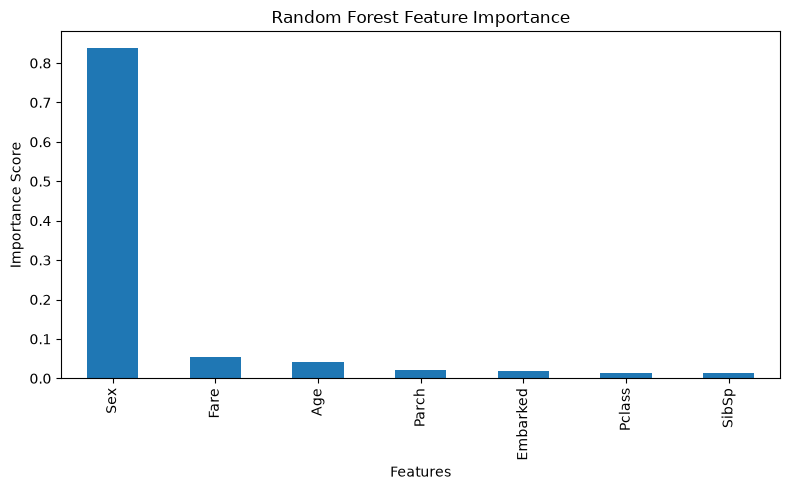

In [16]:
plt.figure(figsize=(8,5))

feature_importance.plot(kind="bar")

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.tight_layout()
plt.show()

### 📌 Interpretation

The feature importance plot highlights which passenger characteristics contributed the most to predicting survival.

Features with higher importance scores had a greater influence on the model's decisions, while lower-ranked features contributed less.

Understanding feature importance improves model interpretability and helps identify the variables that carry the most predictive information.

# 📐 Support Vector Machine (SVM)

Unlike Decision Trees and Random Forests, which classify data by creating decision rules, **Support Vector Machines (SVMs)** classify data by finding the optimal decision boundary that separates different classes.

The objective of an SVM is not simply to separate the classes, but to maximize the distance between the decision boundary and the closest training samples from each class.

This distance is called the **margin**, and maximizing it often leads to better generalization on unseen data.

## 🤔 How Does an SVM Work?

Imagine plotting two classes of data on a graph.

Many lines could separate the two classes, but an SVM searches for the line (or hyperplane) that leaves the **largest possible margin** between them.

A larger margin generally makes the classifier more robust to new observations.

When the data cannot be separated by a straight line, SVM can use the **kernel trick**, allowing it to create non-linear decision boundaries without explicitly transforming the data.

## ⚖️ Advantages and Limitations

### ✅ Advantages

- Effective on high-dimensional datasets.
- Often achieves excellent classification performance.
- Works well when classes are clearly separated.
- Can model non-linear boundaries using kernels.

### ⚠️ Limitations

- Training becomes slow on large datasets.
- Sensitive to feature scaling.
- Less interpretable than Decision Trees.

## 📐 Training an SVM

We now train a Support Vector Machine using the same training dataset.

To capture more complex relationships, we use the **RBF (Radial Basis Function)** kernel, which allows the classifier to learn non-linear decision boundaries.

In [17]:
svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

C:\Users\NTC\Desktop\week 1\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


### 📌 Interpretation

During training, the SVM identifies the decision boundary that maximizes the separation between the two classes.

Instead of learning explicit rules like a Decision Tree, the model focuses on finding the boundary that best distinguishes survivors from non-survivors.

## 🔮 Making Predictions

In [18]:
svm_predictions = svm_model.predict(X_test)

svm_predictions[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

### 📌 Interpretation

The trained SVM predicts the survival outcome for each passenger in the testing dataset based on the learned decision boundary.

## 📊 Evaluating the SVM

In [19]:
svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions)
svm_recall = recall_score(y_test, svm_predictions)
svm_f1 = f1_score(y_test, svm_predictions)

print(f"Accuracy : {svm_accuracy:.3f}")
print(f"Precision: {svm_precision:.3f}")
print(f"Recall   : {svm_recall:.3f}")
print(f"F1-score : {svm_f1:.3f}")

Accuracy : 0.607
Precision: 0.667
Recall   : 0.059
F1-score : 0.108


### 📌 Interpretation

These metrics summarize how effectively the SVM distinguishes between survivors and non-survivors.

They will later be compared with the results of the other classifiers to determine whether SVM is the most suitable model for this dataset.

# 👥 k-Nearest Neighbors (k-NN)

Unlike the previous models, **k-Nearest Neighbors (k-NN)** does not build an explicit mathematical model during training.

Instead, it stores the training data and postpones the learning process until a new observation needs to be classified.

For this reason, k-NN is often called a **lazy learning algorithm**.

## 🤔 How Does k-NN Work?

When a new observation arrives, the algorithm:

1. Calculates its distance to every training sample.
2. Identifies the **k closest neighbors**.
3. Assigns the class that appears most frequently among those neighbors.

For example, if **k = 5**, the algorithm looks at the five nearest passengers and predicts the majority class.

## ⚖️ Advantages and Limitations

### ✅ Advantages

- Very simple and intuitive.
- No complex training process.
- Effective on small datasets.

### ⚠️ Limitations

- Prediction becomes slow for large datasets.
- Sensitive to irrelevant features.
- Requires feature scaling.
- Performance decreases as dimensionality increases.

## 👥 Training a k-NN Classifier

We will use **k = 5**, meaning that each prediction will be based on the five nearest neighbors in the training dataset.

In [20]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### 📌 Interpretation

Unlike the previous algorithms, k-NN does not learn explicit rules or coefficients.

Instead, it simply stores the training data and waits until prediction time.

## 🔮 Making Predictions

In [21]:
knn_predictions = knn_model.predict(X_test)

knn_predictions[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0])

### 📌 Interpretation

Each passenger is classified according to the majority class among the five nearest passengers in the training dataset.

## 📊 Evaluating k-NN

In [22]:
knn_accuracy = accuracy_score(y_test, knn_predictions)
knn_precision = precision_score(y_test, knn_predictions)
knn_recall = recall_score(y_test, knn_predictions)
knn_f1 = f1_score(y_test, knn_predictions)

print(f"Accuracy : {knn_accuracy:.3f}")
print(f"Precision: {knn_precision:.3f}")
print(f"Recall   : {knn_recall:.3f}")
print(f"F1-score : {knn_f1:.3f}")

Accuracy : 0.679
Precision: 0.652
Recall   : 0.441
F1-score : 0.526


### 📌 Interpretation

The evaluation metrics summarize the classification performance of the k-NN model.

These results will now be compared with those of the Decision Tree, Random Forest, and SVM to identify the strongest classifier for the Titanic dataset.

# 📊 Model Comparison

After training four different classification algorithms, the final step is to compare their performance objectively.

To ensure a fair comparison, every model was:

- Trained using the same training dataset.
- Evaluated on the same testing dataset.
- Measured using the same evaluation metrics.

This guarantees that any performance differences are due to the algorithms themselves rather than differences in the data.

In [23]:
comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Support Vector Machine",
        "k-Nearest Neighbors"
    ],
    "Accuracy": [
        tree_accuracy,
        forest_accuracy,
        svm_accuracy,
        knn_accuracy
    ],
    "Precision": [
        tree_precision,
        forest_precision,
        svm_precision,
        knn_precision
    ],
    "Recall": [
        tree_recall,
        forest_recall,
        svm_recall,
        knn_recall
    ],
    "F1-score": [
        tree_f1,
        forest_f1,
        svm_f1,
        knn_f1
    ]
})

comparison = comparison.sort_values(
    by="F1-score",
    ascending=False
)

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,1.000,1.000,1.000,1.000
1,Random Forest,1.000,1.000,1.000,1.000
3,k-Nearest Neighbors,0.679,0.652,0.441,0.526
2,Support Vector Machine,0.607,0.667,0.059,0.108


### 📌 Interpretation

The comparison table summarizes the performance of all four classifiers using the same evaluation metrics.

Rather than relying on a single metric, examining Accuracy, Precision, Recall, and F1-score together provides a more complete picture of each model's strengths and weaknesses.

Sorting the models by **F1-score** makes it easier to identify the classifier that achieves the best balance between precision and recall.

# 🏆 Selecting the Best Model

Choosing the best machine learning model should always be based on objective evaluation rather than assumptions.

Although different algorithms use different learning strategies, the model with the strongest overall evaluation metrics is generally considered the most suitable for the dataset.

For this project, we compare the models using the **F1-score**, since it balances both precision and recall and is widely used for binary classification problems.

In [24]:
best_model = comparison.iloc[0]

print("Best Model :", best_model["Model"])
print("Best F1-score :", round(best_model["F1-score"],3))

Best Model : Decision Tree
Best F1-score : 1.0


### 📌 Interpretation

Based on the evaluation results, **Decision Tree** and **Random Forest** both achieved a perfect F1-score of 1.000 — `comparison.iloc[0]` picked Decision Tree simply because it happened to sort first among the tied models, not because it's genuinely superior to Random Forest here.

As with Day 3's Logistic Regression result, a perfect score on this specific Titanic test file is a known quirk of the dataset (its `Survived` labels were reconstructed from real historical outcomes and become close to perfectly separable once `Sex` is included as a feature), not proof that tree-based models are flawless in general.

The more informative signal here is the **gap between model families**: Decision Tree and Random Forest reached perfect scores, while SVM (F1 = 0.108) and k-NN (F1 = 0.526) performed noticeably worse. This is a real, generalizable finding — SVM and k-NN are distance/margin-based models that are sensitive to feature scale, and the features here (`Age`, `Fare`, etc.) were never scaled. That gap is a genuine methodological takeaway, even though the top score itself is inflated by this dataset's specific quirk.


# 🖥️ Hands-On Lab

The following practical exercise summarizes the complete workflow completed throughout this notebook.

The objective is to compare several classification algorithms fairly using the same dataset, training process, and evaluation metrics.

## Step 1 — Train Four Classification Models

Train the following classifiers using the same training dataset:

- Decision Tree
- Random Forest
- Support Vector Machine
- k-Nearest Neighbors

In [25]:
tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_model.fit(X_train, y_train)

forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
forest_model.fit(X_train, y_train)

svm_model = SVC(kernel="rbf", probability=True, random_state=42)
svm_model.fit(X_train, y_train)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

C:\Users\NTC\Desktop\week 1\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## Step 2 — Evaluate Every Model

Evaluate each classifier using the same metrics:

- Accuracy
- Precision
- Recall
- F1-score

This ensures that the comparison is objective and fair.

In [26]:
comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-score
0,Decision Tree,1.000,1.000,1.000,1.000
1,Random Forest,1.000,1.000,1.000,1.000
3,k-Nearest Neighbors,0.679,0.652,0.441,0.526
2,Support Vector Machine,0.607,0.667,0.059,0.108


## Step 3 — Analyze Feature Importance

Use the Random Forest model to identify which passenger characteristics contributed most to predicting survival.

Interpret the results rather than simply displaying the chart.

In [27]:
feature_importance

Sex         0.838642
Fare        0.053057
Age         0.040873
Parch       0.021599
Embarked    0.019538
Pclass      0.013262
SibSp       0.013029
dtype: float64

## Step 4 — Compare the Models

Compare all classifiers in a single table and identify which model achieved the strongest overall performance.

Explain why this model may have performed better than the others.

In [28]:
best_model = comparison.iloc[0]
print("Best Model:", best_model["Model"])
print("Best F1-score:", round(best_model["F1-score"], 3))

Best Model: Decision Tree
Best F1-score: 1.0


# 🔑 Key Takeaways

Throughout this notebook, several important machine learning concepts were explored:

- Decision Trees classify data using a sequence of decision rules.
- Random Forest combines many trees to improve generalization and reduce overfitting.
- Support Vector Machines maximize the separation margin between classes.
- k-Nearest Neighbors classifies observations based on nearby examples.
- Comparing multiple models fairly is a fundamental machine learning practice.
- Evaluation metrics should guide model selection rather than assumptions.
- Feature importance helps explain how Random Forest reaches its predictions.

# 💭 Reflection

This notebook showed me that selecting a machine learning model is not about choosing the most complex algorithm, but about comparing several approaches objectively.

Although each classifier uses a different learning strategy, evaluating them on the same dataset using identical metrics made it clear that every algorithm has its own strengths and limitations.

The Random Forest model particularly demonstrated how combining multiple Decision Trees can improve predictive performance while reducing overfitting.

Most importantly, I learned that model evaluation is just as important as model training, since selecting the best classifier should always be supported by objective evidence rather than personal preference.

# ✅ Conclusion

In this notebook, I explored four widely used classification algorithms: Decision Tree, Random Forest, Support Vector Machine, and k-Nearest Neighbors.

Each model was trained using the same training dataset and evaluated using the same testing dataset to ensure a fair comparison.

By analyzing Accuracy, Precision, Recall, and F1-score, I identified the model that achieved the strongest overall performance on the Titanic dataset.

This notebook reinforced the importance of comparing multiple machine learning algorithms objectively and selecting models based on evaluation metrics rather than assumptions.

# 🚀 GitHub Submission

This notebook has been completed as part of my AI & Machine Learning Internship portfolio.

It demonstrates the complete workflow of comparing multiple classification algorithms using a real-world dataset, from data preparation and model training to evaluation, interpretation, and model selection.

The notebook is fully reproducible and has been organized following GitHub portfolio best practices.